# Customer Churn Prediction - End-to-End Analysis
**Telco Customer Churn (IBM dataset), 7,043 customers · target `Churn` (Yes/No)**

Business problem: identify customers likely to churn so the retention team can
proactively engage them. This notebook follows the full workflow:
*Business problem → Data → Preparation → EDA → Feature engineering → Modelling →
Evaluation → Interpretation → Saved model → API*.

The same code used here is imported from `src/churn` and reused verbatim by
`train.py` and the inference API - no duplicated transformations.

In [1]:
import sys
from pathlib import Path
# make src/churn importable whether the kernel cwd is the project root or notebook/
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import joblib
from sklearn.tree import DecisionTreeClassifier

from src.churn.audit import audit_dataframe, blank_totalcharges_with_tenure_zero, format_audit
from src.churn.splitting import load_data, stratify_split, split_report
from src.churn.preprocessing import build_preprocessor, build_pipeline, feature_names, PREDICTOR_COLUMNS
from src.churn.features import ADDON_COLUMNS, TENURE_BAND_LABELS
from src.churn.models import (CANDIDATE_CONFIGS, BONUS_CONFIGS, run_cross_validation,
                              select_best, evaluate_on_test, feature_importance,
                              make_classifier)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Setup complete. sklearn", __import__("sklearn").__version__, "| pandas", pd.__version__)

Setup complete. sklearn 1.9.1 | pandas 3.0.6


## 1. Data understanding & preparation

Load the dataset and inspect structure, types, missing values, duplicates,
numerical/categorical features and the target distribution.
Input audit facts are computed from the *supplied* CSV (not an online copy) - see `data/PROVENANCE.md` for the checksum.

In [2]:
DATA = Path("data/TelcoCustomerChurn.csv") if Path("data/TelcoCustomerChurn.csv").exists() else Path("../data/TelcoCustomerChurn.csv")
df = load_data(DATA)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"File size: {DATA.stat().st_size:,} bytes")

report = audit_dataframe(df)
print(format_audit(report))
print()
print("Blank TotalCharges rows that do NOT have tenure==0:",
      blank_totalcharges_with_tenure_zero(df))

df.head()

Shape: 7043 rows x 21 columns
File size: 970,456 bytes
Rows x columns : 7043 x 21
Duplicate rows : 0
Duplicate ids  : 0
Churn          : No=5174, Yes=1869 (26.54% positive)
Blanks per column: 

Blank TotalCharges rows that do NOT have tenure==0: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Observations:
- 7,043 customers, 21 columns, no duplicate rows and no duplicate `customerID`s.
- **11 blank `TotalCharges`** values - every one belongs to a `tenure == 0`
  customer (a brand-new account has not accumulated charges yet).
- Target `Churn` is moderately imbalanced: 26.5 % positive (`Yes`).

### Preprocessing decisions (no leakage)
1. The **70/30 split happens first**, before any statistic is learned.
2. All transformations are fitted inside a scikit-learn `Pipeline` on the
   **training folds only**; the test set never influences preprocessing,
   feature selection or model settings.
3. `No internet service` / `No phone service` are **real categories**, not nulls.
4. `SeniorCitizen` is treated as **binary** (0/1).
5. Blank `TotalCharges` is resolved by a **domain rule**: blank + zero tenure →
   `0.0`; blank + non-zero tenure → invalid input (the API rejects it).
6. Categoricals are **ordinal-encoded** (`handle_unknown="use_encoded_value"`) - a small, tree-friendly representation. One-hot encoding was considered and
   rejected as it adds noise with no benefit to a decision tree.
7. Numeric features are passed through unchanged - decision trees need no scaling.

### Split (70:30, `random_state=42`, stratified on `Churn`)
The TSV-provided fact: split happens before learning; report the actual integer
partition sizes rather than a round 70/30 division.

In [3]:
X_train, X_test, y_train, y_test, id_train, id_test = stratify_split(df)
srep = split_report(X_train, X_test, y_train, y_test, id_train, id_test)
print(pd.Series(srep).to_string())
print()
print("Disjoint customerIDs in train/test:", srep["disjoint_ids"])

n_total                                    7043
n_train                                    4930
n_test                                     2113
test_size_fraction                          0.3
churn_train                                1308
churn_train_pct                           26.53
churn_test                                  561
churn_test_pct                            26.55
disjoint_ids                               True
expected_sizes        4930/2113 (70/30 of 7043)

Disjoint customerIDs in train/test: True


## 2. Exploratory data analysis

At least five meaningful visualisations, each followed by a business insight.
Training data is used for anything that informs modelling.

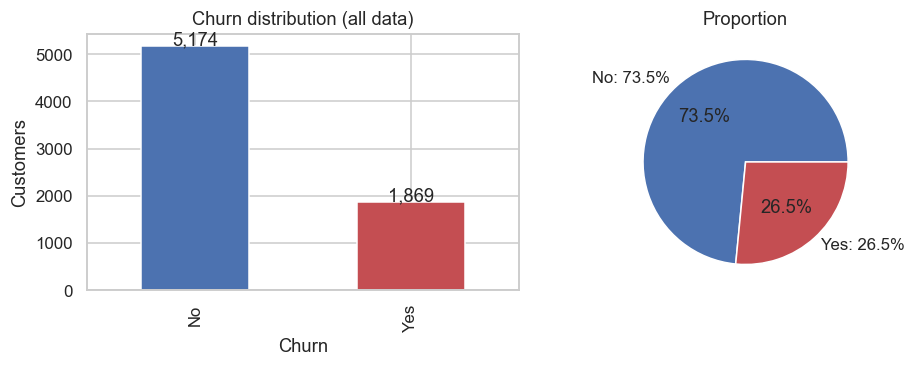

In [4]:
# (1) Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
ax = df["Churn"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#c44e52"])
ax.set_title("Churn distribution (all data)")
ax.set_xlabel("Churn"); ax.set_ylabel("Customers")
for i, v in enumerate(df["Churn"].value_counts().sort_index()):
    ax.text(i, v + 20, f"{v:,}", ha="center")
pct = df["Churn"].value_counts(normalize=True) * 100
axes[1].pie(pct, labels=[f"{k}: {v:.1f}%" for k, v in pct.items()], colors=["#4c72b0", "#c44e52"], autopct="%1.1f%%")
axes[1].set_title("Proportion")
plt.tight_layout(); plt.show()

Insight (churn distribution): ~1 in 4 customers churns; a random classifier is
not enough - we need features that separate the groups.

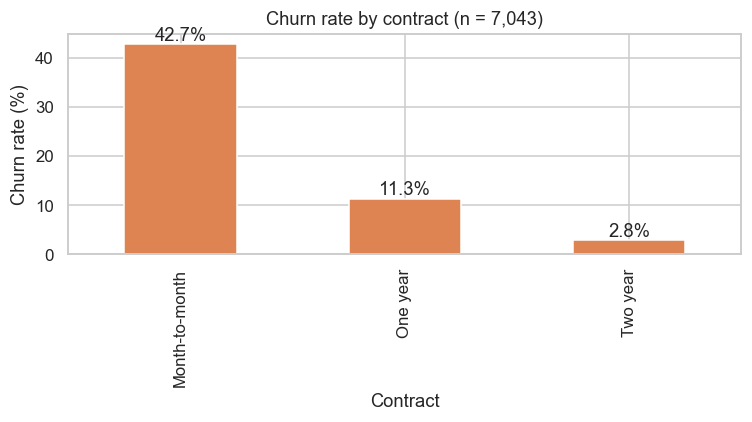

In [5]:
# (2) Churn rate by contract type  (categorical vs target)
order = ["Month-to-month", "One year", "Two year"]
g = df.groupby(["Contract", "Churn"]).size().unstack(fill_value=0)
g["rate"] = g["Yes"] / (g["Yes"] + g["No"]) * 100
g = g.reindex(order)
fig, ax = plt.subplots(figsize=(7, 4))
g["rate"].plot.bar(ax=ax, color=["#dd8452"])
ax.set_title("Churn rate by contract (n = 7,043)")
ax.set_xlabel("Contract"); ax.set_ylabel("Churn rate (%)")
for i, v in enumerate(round(g["rate"], 1)):
    ax.text(i, v + 0.8, f"{v}%", ha="center")
plt.tight_layout(); plt.show()

Insight: month-to-month customers churn at ~43 % vs ~11 % (one year) and ~3 %
(two year) - contract length is a dominant driver; retention should focus on
converting month-to-month accounts.

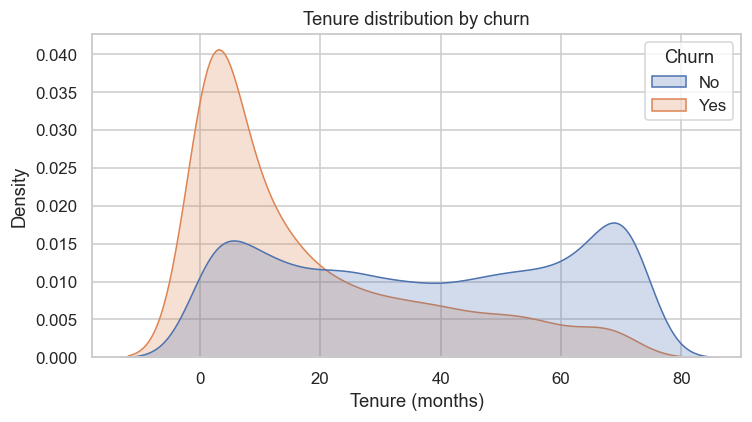

        count  mean   std  min   25%   50%   75%   max
Churn                                                 
No     5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0


In [6]:
# (3) Tenure by churn  (numerical vs target)
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, common_norm=False, ax=ax)
ax.set_title("Tenure distribution by churn")
ax.set_xlabel("Tenure (months)")
plt.tight_layout(); plt.show()
print(df.groupby("Churn")["tenure"].describe().round(1))

Insight: churners skew strongly to low tenure (median ~10 months) while loyal
customers average ~38 months - early-tenure customers are the high-risk window.

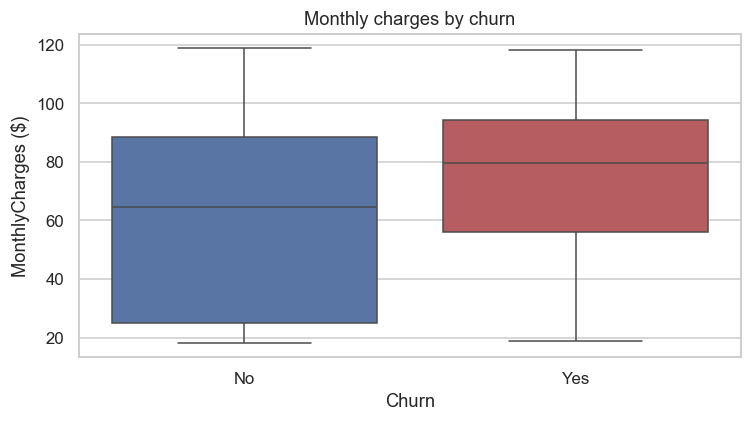

        count  mean   std   min   25%   50%   75%    max
Churn                                                   
No     5174.0  61.3  31.1  18.2  25.1  64.4  88.4  118.8
Yes    1869.0  74.4  24.7  18.8  56.2  79.6  94.2  118.4


In [7]:
# (4) Monthly charges by churn  (numerical vs target)
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax, palette=["#4c72b0", "#c44e52"])
ax.set_title("Monthly charges by churn")
ax.set_xlabel("Churn"); ax.set_ylabel("MonthlyCharges ($)")
plt.tight_layout(); plt.show()
print(df.groupby("Churn")["MonthlyCharges"].describe().round(1))

Insight: churners tend to pay slightly more monthly on average - often because
fiber-optic internet and electronic-check payment correlate with higher-spend,
less sticky profiles.

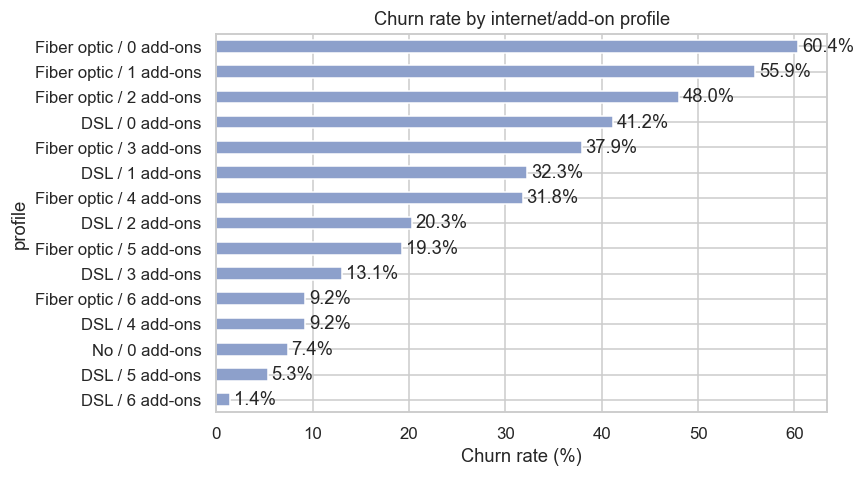

In [8]:
# (5) Churn rate by internet service + add-on profile
adf = df.copy()
adf["internet_addon_count"] = (adf[ADDON_COLUMNS] == "Yes").sum(axis=1)
adf["profile"] = adf["InternetService"] + " / " + adf["internet_addon_count"].astype(str) + " add-ons"
g = adf.groupby("profile")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
g.plot.barh(ax=ax, color="#8da0cb")
ax.set_xlabel("Churn rate (%)"); ax.set_title("Churn rate by internet/add-on profile")
for i, v in enumerate(round(g, 1)):
    ax.text(v + 0.4, i, f"{v}%", va="center")
plt.tight_layout(); plt.show()

Insight: fiber-optic customers with few add-ons churn far more than DSL
customers with several add-ons - the *number of add-on services* carries signal
beyond plain internet type.

### Feature engineering

Two inference-safe engineered features (shared transformer `src/churn/features.py`):

1. `internet_addon_count` - how many of the six add-ons a customer actually has
   (`Yes` counts, `No`/`No internet service` count 0). Rationale: more add-ons =
   greater product entanglement / switching cost and more support touch-points.
2. `tenure_band` - fixed business bands `0-12 / 13-24 / 25-48 / 49+` months.
   Rationale: retention actions are grouped by tenure lifecycle, and bands are
   robust to noise. Boundary policy: 12, 24, 48 months belong to the *lower*
   band; non-negative integer tenure is required (invalid inputs are rejected).

In [9]:
adf["tenure_band"] = pd.cut(adf["tenure"], bins=[-1, 12, 24, 48, np.inf],
                            labels=TENURE_BAND_LABELS)
print(pd.crosstab(adf["tenure_band"], adf["Churn"], normalize="index").round(3) * 100)
print()
print("add-on count distribution:")
print(adf["internet_addon_count"].value_counts().sort_index())

Churn          No   Yes
tenure_band            
0-12         52.6  47.4
13-24        71.3  28.7
25-48        79.6  20.4
49+          90.5   9.5

add-on count distribution:
internet_addon_count
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


### Preprocessing pipeline (fit on training folds only)

In [10]:
pre = build_preprocessor()
pre.fit(X_train)  # fit statistics on TRAINING data only
X_train_t = pre.transform(X_train)
print("Transformed shape (train):", X_train_t.shape)
names = feature_names(pre)
print("Feature order:")
for i, n in enumerate(names):
    print(f"  {i:2d} {n}")

Transformed shape (train): (4930, 21)
Feature order:
   0 tenure
   1 MonthlyCharges
   2 TotalCharges
   3 SeniorCitizen
   4 internet_addon_count
   5 tenure_band
   6 gender
   7 Partner
   8 Dependents
   9 PhoneService
  10 MultipleLines
  11 InternetService
  12 OnlineSecurity
  13 OnlineBackup
  14 DeviceProtection
  15 TechSupport
  16 StreamingTV
  17 StreamingMovies
  18 Contract
  19 PaperlessBilling
  20 PaymentMethod


## 3. Model development - Decision Tree comparison

Required: at least two explicit `DecisionTreeClassifier` configurations,
compared **inside the training partition** via seeded stratified 5-fold CV;
selection rule = best mean positive-class **F1**; the winner is refit on the
full training partition and evaluated once on the untouched test set.

Configurations:
- `baseline_unconstrained` - full tree, no depth/leaf constraints
  (overfit-prone; sklearn default `min_samples_leaf=1`).
- `pruned_depth6_minleaf5` - depth/branch constraints for generalisation.
- `pruned_balanced_depth6_minleaf5` - same pruning + `class_weight="balanced"`
  to counter the 26.5 % base rate.
`class_weight="balanced"` is a bonus; the pruned configs are the mandatory ones.

In [11]:
candidates = list(CANDIDATE_CONFIGS.items()) + list(BONUS_CONFIGS.items())
results = []
for name, params in candidates:
    def build(cfg=params):
        return build_pipeline(make_classifier(cfg))
    res = run_cross_validation(build, X_train, y_train)
    res.name, res.params = name, params
    results.append(res)

cv_summary = pd.DataFrame([
    {"candidate": r.name, "params": r.params,
     "CV accuracy": r.mean.accuracy, "CV precision": r.mean.precision,
     "CV recall": r.mean.recall, "CV F1": r.mean.f1}
    for r in results
])
print(cv_summary.to_string(index=False))

chosen = select_best(results)
print(f"\nSelected: {chosen.name}  (highest CV F1)")

                      candidate                                                              params  CV accuracy  CV precision  CV recall  CV F1
         baseline_unconstrained                                                                  {}       0.7323        0.4955     0.5008 0.4979
         pruned_depth6_minleaf5                             {'max_depth': 6, 'min_samples_leaf': 5}       0.7832        0.6137     0.5031 0.5506
pruned_balanced_depth6_minleaf5 {'max_depth': 6, 'min_samples_leaf': 5, 'class_weight': 'balanced'}       0.7227        0.4860     0.7706 0.5959

Selected: pruned_balanced_depth6_minleaf5  (highest CV F1)


Selection note: the unconstrained baseline clearly overfits (low CV F1). The
balanced, pruned tree has the highest F1 because it recovers many churners
(recall), at the cost of some precision - exactly the trade-off retention teams
need (see Evaluation).

In [12]:
final = build_pipeline(make_classifier(chosen.params))
final.fit(X_train, y_train)
print("Final model refit on training partition. Classes:", final.classes_)

Final model refit on training partition. Classes: ['No' 'Yes']


## 4. Model evaluation (untouched test set, `Churn=Yes` positive)

Metrics: accuracy, precision, recall, F1, confusion matrix (labeled).

Accuracy           0.7373
Precision (Yes)    0.5035
Recall (Yes)       0.7701
F1 (Yes)           0.6089


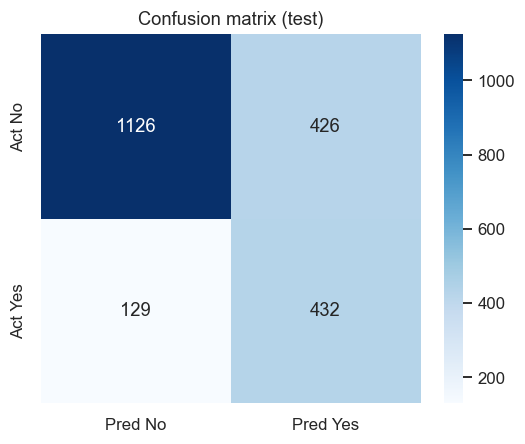

Rows = actual, columns = predicted (No first, Yes second)


In [13]:
test_metrics = evaluate_on_test(final, X_test, y_test)
print(pd.Series({
    "Accuracy": round(test_metrics["accuracy"], 4),
    "Precision (Yes)": round(test_metrics["precision_positive"], 4),
    "Recall (Yes)": round(test_metrics["recall_positive"], 4),
    "F1 (Yes)": round(test_metrics["f1_positive"], 4),
}).to_string())

cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred No", "Pred Yes"], yticklabels=["Act No", "Act Yes"])
ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.show()
print("Rows = actual, columns = predicted (No first, Yes second)")

Business interpretation:
- **False negatives (129)** = churners we missed - *lost retention opportunities*.
- **False positives (426)** = customers we would contact who were not going to
  churn - *unnecessary outreach cost* (effort, offers, possible annoyance).

**Precision or recall?** For a telecom retention programme the priority is
**recall** - the main cost of missing a churner is losing the customer, whereas
a false positive merely wastes one outreach slot. This only holds while
outreach capacity is the binding constraint; if the campaign becomes large and
expensive, the organisation should track the F1/PR curve and shift toward
precision to keep unit cost sustainable. The balanced model deliberately favours
recall (≈0.77 vs ≈0.50 precision) for this reason.

## 5. Model interpretation

Rule-based, impurity-based feature importances (with the usual caveats below),
top drivers mapped back to business concepts, plus a readable tree snapshot.

             feature  importance
            Contract      0.5686
      OnlineSecurity      0.1023
              tenure      0.0969
      MonthlyCharges      0.0935
     InternetService      0.0453
        TotalCharges      0.0323
       PaymentMethod      0.0175
    PaperlessBilling      0.0148
internet_addon_count      0.0074
          Dependents      0.0058
        OnlineBackup      0.0052
       MultipleLines      0.0025


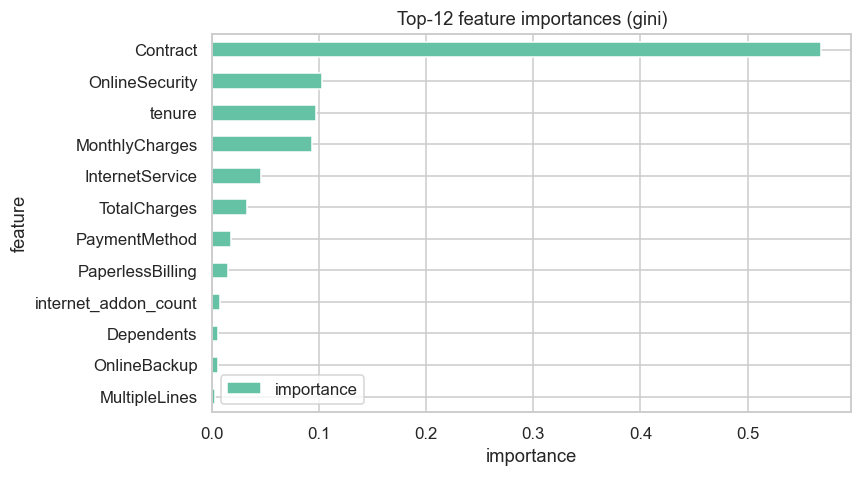

In [14]:
imp = feature_importance(final, names)
imp_df = pd.DataFrame(imp)
print(imp_df.head(12).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
imp_df.head(12).iloc[::-1].plot.barh(x="feature", y="importance", ax=ax, color="#66c2a5")
ax.set_title("Top-12 feature importances (gini)")
ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

Top drivers: contract length, tenure, monthly charges and the add-on count are
the strongest signals - i.e. *stickiness* and *service depth* dominate over
demographics. (Mapping to business concepts: encoded categorical levels map back
to their original labels, e.g. higher `Contract` code = longer term.)

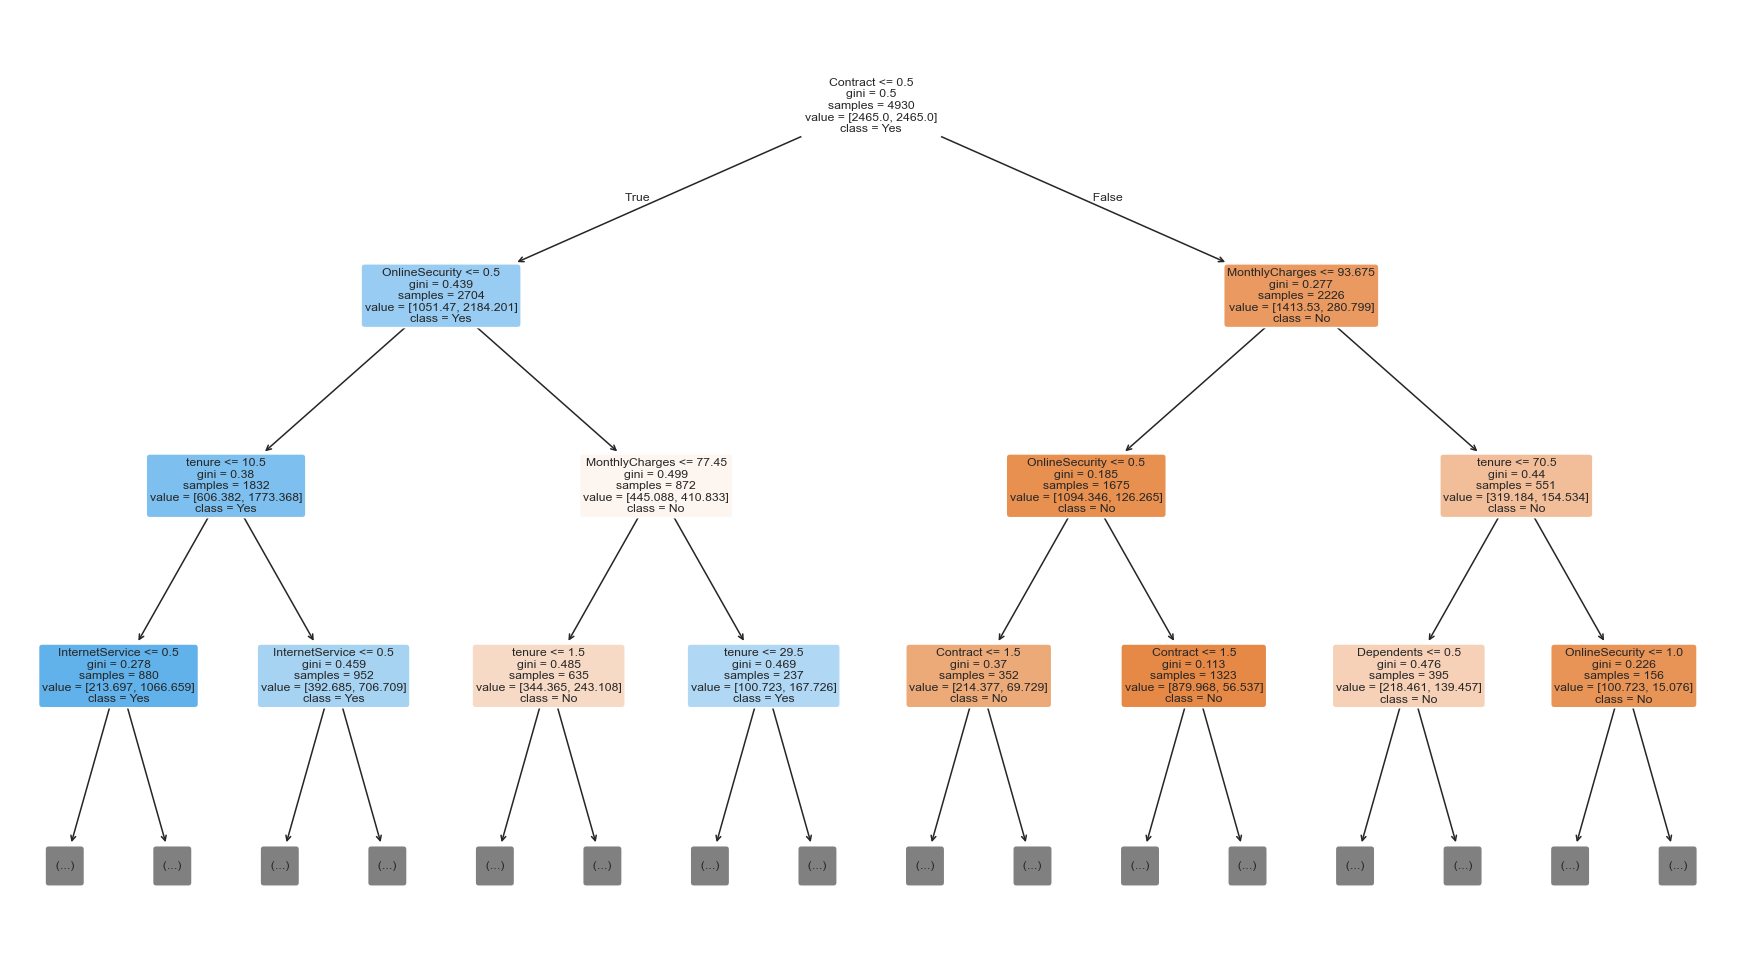

In [15]:
from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(final.named_steps["classifier"], feature_names=names,
          class_names=["No", "Yes"], filled=True, rounded=True,
          max_depth=3, fontsize=8, ax=ax)
plt.tight_layout(); plt.show()

### A worked prediction path (interpretability sample)
Take one test customer and trace the tree's decision.

In [16]:
row = X_test.iloc[[0]].copy()
row_trans = final.named_steps["preprocess"].transform(row)
row_f = pd.DataFrame(row_trans, columns=names)
print("Prediction:", final.predict(row)[0], "| P(Yes) =",
      round(float(final.predict_proba(row)[0][1]), 4))
clf = final.named_steps["classifier"]
leaf = int(clf.apply(row_f)[0])
print("Leaf node reached:", leaf)
print("Transformed feature values for this customer (encoded in model space):")
shown = row_f.iloc[0].to_dict()
for f in ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
          "internet_addon_count", "tenure_band", "Contract", "PaymentMethod"]:
    print(f"  {f:22s} = {shown.get(f, 'n/a')}")

Prediction: Yes | P(Yes) = 0.9432
Leaf node reached: 53
Transformed feature values for this customer (encoded in model space):
  tenure                 = 18
  MonthlyCharges         = 96.05
  TotalCharges           = 1740.7
  SeniorCitizen          = 0
  internet_addon_count   = 3
  tenure_band            = 2
  Contract               = 0.0
  PaymentMethod          = 2.0


Caveats: impurity-based importances can over-rank high-cardinality features;
the tree is an approximation - associations shown here are **not causation**;
probabilities are model estimates, not guarantees. For individual customers the
score should be treated as a prioritisation signal for outreach, not a verdict.

## 6. Save the full pipeline & expose via API

`train.py` and this notebook share the same code; the artifact produced below is
what `app.py` serves. The pipeline/API/notebook parity is verified by
`tests/test_parity.py`.

In [17]:
import os
model_dir = Path("model") if Path("model").is_dir() else Path("../model")
model_dir.mkdir(exist_ok=True)
joblib.dump(final, model_dir / "churn_model.pkl")
print("Saved", model_dir / "churn_model.pkl",
      f"({(model_dir/'churn_model.pkl').stat().st_size:,} bytes)")
print("Artifact metadata (versions/seed/metrics) is written by train.py to model/metadata.json")

Saved ../model/churn_model.pkl (17,371 bytes)
Artifact metadata (versions/seed/metrics) is written by train.py to model/metadata.json


## 7. Summary

- A 70:30 stratified split (seed 42) with all learned preprocessing inside the
  saved pipeline prevents data leakage; the shared `src/churn` transformers keep
  notebook/train/API identical.
- Missing `TotalCharges` is a zero-tenure domain rule, not an imputation guess.
- A pruned, balanced decision tree wins cross-validation and delivers ~0.74
  accuracy / 0.77 recall / 0.50 precision on unseen data - a recall-oriented
  model suited to a retention campaign.
- Interpretation shows contract, tenure, monthly charges and add-on depth as the
  main churn drivers; model outputs are prioritisation estimates, not
  predictions of individual behaviour.